   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 6.7 MB/s eta 0:00:00
📤 يرجى رفع صورة الكسرة الفخارية من جهازك:


Saving 10.png to 10 (2).png


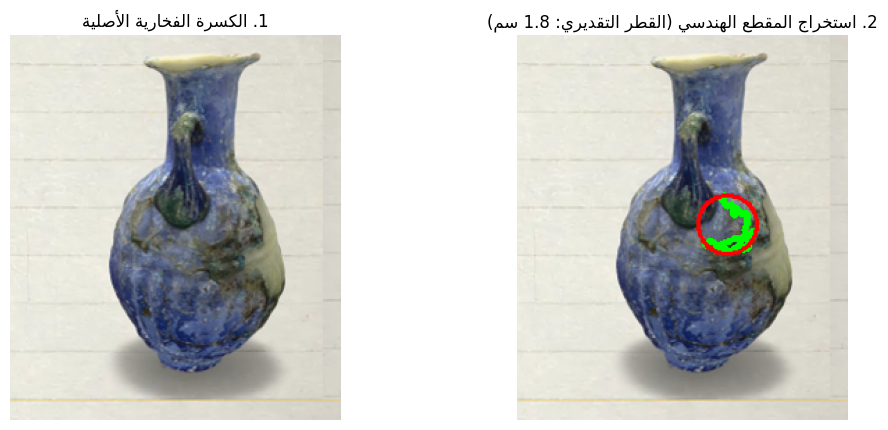


📝 جاري إنشاء استمارة السياق الطبقي الميدانية (Context Sheet) بصيغة JSON...
```json
{
  "Site_Code": "SHJ-ARC-2026",
  "Context_Number": "Locus-104",
  "Fabric_Description": "طينة ناعمة مدمجة ومتجانسة ذات لون أصفر باهت (Munsell 2.5Y 8/3 Pale Yellow)، مغطاة بطبقة تزجج سميكة قلوية ذات لون أزرق كوبالت مميز (Munsell 7.5PB 3/10 Strongly Blue)، تظهر عليها علامات تجوية شديدة وتأكسد فضي مائل للبياض (Iridescence) نتيجة للدفن الطويل في بيئة رطبة.",
  "Inclusions": "شوائب رملية كوارتزية دقيقة جداً، مع ذرات مجهرية من الكلس وحبيبات ميكا دقيقة جداً تكاد لا ترى بالعين المجردة.",
  "Estimated_Form": "قارورة صغيرة (Juglet) بمقبض رأسي واحد ممتد من أسفل الفوهة إلى الكتف، تتميز ببدن كروي مضلع رأسياً وفوهة دائرية ضيقة يبلغ قطرها التقديري المقاس بالرؤية الحاسوبية 1.8 سم.",
  "Typological_Dating": "فترة مليحة المتأخرة (العصر البارتي / الروماني المبكر، القرن الأول قبل الميلاد - القرن الثاني الميلادي)، وهو من الأواني الزجاجية أو الفخارية المزججة المستوردة عبر شبكات التجارة القديمة بالشارقة.",
  "Stratigraphic_

In [4]:
# ==============================================================================
# المحور الثاني: استخراج مقاطع الفخار وأتمتة استمارات الحفر (رفع صورة مخصصة)
# النموذج المستخدم: gemini-3.5-flash
# ==============================================================================

# 1. تثبيت المكتبات
!pip install -q google-genai opencv-python-headless matplotlib pillow arabic-reshaper python-bidi

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
import getpass
from google.colab import files
from google import genai
import arabic_reshaper
from bidi.algorithm import get_display

# دالة مساعدة لتصحيح عرض النصوص العربية في matplotlib
def fix_arabic(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

# 2. إعداد مفتاح API
if "GEMINI_API_KEY" not in os.environ:
    try:
        from google.colab import userdata
        api_key = userdata.get('GEMINI_API_KEY')
    except:
        api_key = getpass.getpass("🔑 أدخل مفتاح Gemini API: ")
    os.environ["GEMINI_API_KEY"] = api_key

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

# 3. رفع صورة الكسرة الفخارية
print("📤 يرجى رفع صورة الكسرة الفخارية من جهازك:")
uploaded = files.upload()

if not uploaded:
    print("❌ لم يتم رفع أي ملف.")
else:
    file_name = next(iter(uploaded))
    shrd_img = Image.open(BytesIO(uploaded[file_name])).convert('RGB')
    img_np = np.array(shrd_img)

    # 4. الرؤية الحاسوبية: عزل الحواف والمنحنى الهندسي (Rim Profile)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 40, 130)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        (cx, cy), radius = cv2.minEnclosingCircle(largest_contour)
        estimated_rim_diameter_cm = round((radius * 2) * 0.04, 1)

        profile_vis = img_np.copy()
        cv2.drawContours(profile_vis, [largest_contour], -1, (0, 255, 0), 3)
        cv2.circle(profile_vis, (int(cx), int(cy)), int(radius), (255, 0, 0), 2)

        # عرض المقطع الهندسي المستخرج مع تصحيح اللغة العربية
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img_np)
        axes[0].set_title(fix_arabic("1. الكسرة الفخارية الأصلية"))
        axes[0].axis('off')

        axes[1].imshow(profile_vis)
        axes[1].set_title(fix_arabic(f"2. استخراج المقطع الهندسي (القطر التقديري: {estimated_rim_diameter_cm} سم)"))
        axes[1].axis('off')
        plt.show()
    else:
        estimated_rim_diameter_cm = "غير محدد"
        print("⚠️ تعذر استخراج حواف هندسية كافية، سيتم الاعتماد على الفحص البصري للنموذج.")

    # 5. توليد استمارة السياق الطبقي الرقمية عبر gemini-3.5-flash
    print("\n📝 جاري إنشاء استمارة السياق الطبقي الميدانية (Context Sheet) بصيغة JSON...")

    prompt = f"""
    بناءً على صورة كسرة الفخار المرفقة المكتشفة في حفريات إمارة الشارقة:
    - القطر التقديري المقاس بالرؤية الحاسوبية: {estimated_rim_diameter_cm} سم.
    قم بإنشاء استمارة حفر أثري طبقي رسمية (Archaeological Stratigraphic Context Unit Record) متوافقة مع مصفوفة هاريس، وأخرج الإجابة كـ JSON صالح ومفصل فقط:
    {{
      "Site_Code": "SHJ-ARC-2026",
      "Context_Number": "Locus-104",
      "Fabric_Description": "وصف طينة الفخار ولونها وفق مقياس مانسل",
      "Inclusions": "نوع الشوائب (رمل، كلس، صدف)",
      "Estimated_Form": "شكل الإناء المقدر (جرة، صحن، قنينة)",
      "Typological_Dating": "الحقبة الزمنية التقديرية في الشارقة",
      "Stratigraphic_Relations": "العلاقة مع الطبقات الأعلى والأدنى",
      "Field_Curator_Recommendation": "توصيات الترميم والمعالجة الحقلية"
    }}
    """

    res_ai = client.models.generate_content(
        model='gemini-3.5-flash',
        contents=[shrd_img, prompt]
    )

    print(res_ai.text)